# 07 - DS Cadrage mÃ©tier, QualitÃ© des donnÃ©es et Design de validation

Objectif: montrer la dÃ©marche **avant** la modÃ©lisation.

Ce notebook documente:
- le problÃ¨me mÃ©tier (tarification, frÃ©quence Ã— sÃ©vÃ©ritÃ©),
- la comprÃ©hension des colonnes,
- la qualitÃ© des donnÃ©es (NA, incohÃ©rences, outliers),
- la dÃ©rive train/test (drift/OOD),
- la justification des splits de validation anti-fuite.


## Cadrage mÃ©tier (avant de coder)

**Constat**
- La prime doit Ãªtre compÃ©titive et rentable.
- Une grosse erreur de tarification est trÃ¨s coÃ»teuse.

**InterprÃ©tation**
- Une dÃ©composition actuarielle `frÃ©quence Ã— sÃ©vÃ©ritÃ©` est naturelle et explicable.
- La mÃ©trique RMSE est cohÃ©rente car elle pÃ©nalise fortement les grosses erreurs.

**DÃ©cision**
- On documente la dÃ©marche two-part et on relie chaque choix de preprocessing/CV Ã  ce cadre.


**Convention de commentaire dans ce notebook (Ã  respecter dans l'analyse)**

- `Constat` : ce que montrent les chiffres/graphes
- `InterprÃ©tation` : ce que cela signifie (avec prudence)
- `DÃ©cision` : impact pratique sur preprocessing / CV / modÃ¨le
- Terminer chaque bloc par une phrase `Impact modÃ¨le attendu`


In [1]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR
for _candidate in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
    if (_candidate / "src").exists() and (_candidate / "data").exists():
        ROOT = _candidate
        break
else:
    raise RuntimeError("Project root not found. Expected folders: src/ and data/.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
ARTIFACTS_DIR = ROOT / "artifacts"    

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

from src.insurance_pricing.training import ensure_dir
import src.insurance_pricing.training as v2
from src.insurance_pricing.analytics import *

DATA_DIR = ROOT / "data"
ARTIFACT_DS = ensure_dir(ROOT / DEFAULT_DS_DIR)
ARTIFACT_V2 = ROOT / v2.DEFAULT_V2_DIR

SEED = 42
QUICK_ANALYSIS = True
FULL_ANALYSIS = False
SAMPLE_N = 3000
np.random.seed(SEED)


In [2]:
train_raw, test_raw = load_project_datasets(DATA_DIR)
print("train:", train_raw.shape, "test:", test_raw.shape)
display(train_raw.head(2))
display(test_raw.head(2))


train: (50000, 33) test: (50000, 28)


,index,id_client,id_vehicule,id_contrat,bonus,type_contrat,duree_contrat,anciennete_info,freq_paiement,paiement,...,marque_vehicule,modele_vehicule,debut_vente_vehicule,fin_vente_vehicule,vitesse_vehicule,type_vehicule,prix_vehicule,poids_vehicule,nombre_sinistres,montant_sinistre
0,0,A00000001,V01,A00000001-V01,0.5,Maxi,29,9,Biannual,No,...,PEUGEOT,306,10,9,182,Tourism,20700,1210,0,0.0
1,1,A00000002,V01,A00000002-V01,0.5,Maxi,3,1,Biannual,No,...,MERCEDES BENZ,C220,4,2,229,Tourism,34250,1510,0,0.0


,index,bonus,type_contrat,duree_contrat,anciennete_info,freq_paiement,paiement,utilisation,code_postal,conducteur2,...,din_vehicule,essence_vehicule,marque_vehicule,modele_vehicule,debut_vente_vehicule,fin_vente_vehicule,vitesse_vehicule,type_vehicule,prix_vehicule,poids_vehicule
0,50000,0.58,Maxi,1,1,Yearly,No,Retired,28388,No,...,55,Gasoline,RENAULT,CLIO,16,15,150,Tourism,10321,830
1,50001,0.50,Median2,2,2,Yearly,No,Retired,19123,No,...,96,Diesel,MERCEDES BENZ,C220,16,12,175,Tourism,24652,1400


In [3]:
# Data contract + dictionnaire de donnÃ©es
data_dict = build_data_dictionary(train_raw, test_raw)
col_types = classify_columns(train_raw, test_raw)
leakage_risk = detect_leakage_risk_columns(train_raw)

display(data_dict.head(20))
display(col_types[["column","role_guess","dtype_train","nunique_train","missing_rate_train","high_cardinality_train"]].head(20))
display(leakage_risk)


,column,present_train,present_test,dtype_train,dtype_test,nunique_train,nunique_test,missing_rate_train,missing_rate_test,sample_values_train,role_guess
0,code_postal,1,1,object,object,12790,12806.0,0.00000,0.00000,36233 | 92073 | 92026,categorical
1,conducteur2,1,1,object,object,2,2.0,0.00000,0.00000,No | No | No,categorical
2,essence_vehicule,1,1,object,object,3,3.0,0.00000,0.00000,Gasoline | Diesel | Gasoline,categorical
3,freq_paiement,1,1,object,object,4,4.0,0.00000,0.00000,Biannual | Biannual | Yearly,categorical
4,marque_vehicule,1,1,object,object,89,88.0,0.00000,0.00000,PEUGEOT | MERCEDES BENZ | BMW,categorical
5,modele_vehicule,1,1,object,object,886,894.0,0.00000,0.00000,306 | C220 | Z3,categorical
6,paiement,1,1,object,object,2,2.0,0.00000,0.00000,No | No | No,categorical
7,sex_conducteur1,1,1,object,object,2,2.0,0.00000,0.00000,M | M | M,categorical
8,sex_conducteur2,1,1,object,object,3,3.0,0.66812,0.66816,F | M | F,categorical
9,type_contrat,1,1,object,object,4,4.0,0.00000,0.00000,Maxi | Maxi | Maxi,categorical


,column,role_guess,dtype_train,nunique_train,missing_rate_train,high_cardinality_train
0,code_postal,categorical,object,12790,0.00000,1
1,conducteur2,categorical,object,2,0.00000,0
2,essence_vehicule,categorical,object,3,0.00000,0
3,freq_paiement,categorical,object,4,0.00000,0
4,marque_vehicule,categorical,object,89,0.00000,0
5,modele_vehicule,categorical,object,886,0.00000,1
6,paiement,categorical,object,2,0.00000,0
7,sex_conducteur1,categorical,object,2,0.00000,0
8,sex_conducteur2,categorical,object,3,0.66812,0
9,type_contrat,categorical,object,4,0.00000,0


,column,risk_types,risk_level,recommended_action,rule_matched
0,id_client,identifier,high,exclude_as_feature,identifier_exact
1,id_contrat,identifier,high,exclude_as_feature,identifier_exact
2,id_vehicule,identifier,high,exclude_as_feature,identifier_exact
3,index,identifier,high,exclude_as_feature,identifier_exact
4,montant_sinistre,target,high,target_only,target_exact
5,nombre_sinistres,target,high,target_only,target_exact


**Ã€ commenter (cellule prÃ©cÃ©dente)**

- `Constat`: quelles colonnes sont des identifiants (`index`, `id_client`, `id_vehicule`, `id_contrat`) ?
- `InterprÃ©tation`: pourquoi ces colonnes crÃ©ent un risque de fuite ou d'apprentissage non gÃ©nÃ©ralisable ?
- `DÃ©cision`: colonnes Ã  exclure comme features brutes.
- **Impact modÃ¨le attendu**: baisse du risque d'overfitting et meilleure robustesse privÃ©e.


,metric,value
0,n_train,50000.000000
1,claim_rate,0.058340
2,n_claims_pos,2917.000000
3,sev_mean_pos,1771.843401
4,sev_median_pos,1236.000000
5,sev_q95_pos,4355.258000
6,sev_q99_pos,6963.118800
7,sev_max_pos,21826.960000


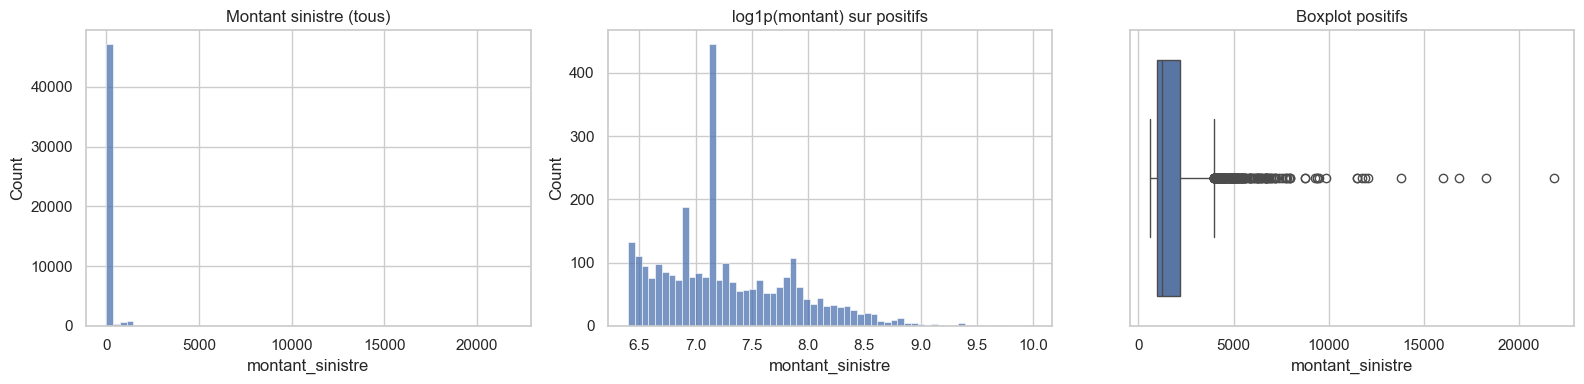

In [4]:
# Cibles frÃ©quence / sÃ©vÃ©ritÃ©
y_sev = train_raw[v2.TARGET_SEV_COL].astype(float)
y_freq = (y_sev > 0).astype(int)
y_pos = y_sev[y_sev > 0]

target_summary = pd.DataFrame([
    {"metric": "n_train", "value": len(train_raw)},
    {"metric": "claim_rate", "value": float(y_freq.mean())},
    {"metric": "n_claims_pos", "value": int(y_freq.sum())},
    {"metric": "sev_mean_pos", "value": float(y_pos.mean()) if len(y_pos) else np.nan},
    {"metric": "sev_median_pos", "value": float(y_pos.median()) if len(y_pos) else np.nan},
    {"metric": "sev_q95_pos", "value": float(y_pos.quantile(0.95)) if len(y_pos) else np.nan},
    {"metric": "sev_q99_pos", "value": float(y_pos.quantile(0.99)) if len(y_pos) else np.nan},
    {"metric": "sev_max_pos", "value": float(y_pos.max()) if len(y_pos) else np.nan},
])
display(target_summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(y_sev, bins=60, ax=axes[0])
axes[0].set_title("Montant sinistre (tous)")
sns.histplot(np.log1p(y_pos), bins=60, ax=axes[1])
axes[1].set_title("log1p(montant) sur positifs")
sns.boxplot(x=y_pos, ax=axes[2], orient="h")
axes[2].set_title("Boxplot positifs")
plt.tight_layout()


**Ã€ commenter**
- `Constat`: raretÃ© des sinistres + forte asymÃ©trie / queue lourde de la sÃ©vÃ©ritÃ©.
- `InterprÃ©tation`: pourquoi `log1p` et/ou Tweedie sont des candidats naturels.
- `DÃ©cision`: conserver l'approche two-part et soigner la couverture de queue.


,scope,group_col,group_value,column,present_train,present_test,applicable_train,applicable_test,missing_rate_train,missing_rate_test,missing_rate_train_effective,missing_rate_test_effective,missing_rate_train_filled,missing_rate_test_filled,missing_gap_test_minus_train
292,global,None,None,sex_conducteur2,1,1,1,1,0.66812,0.66816,0.66812,0.66816,0.66812,0.66816,0.00004
269,global,None,None,anciennete_vehicule,1,1,1,1,0.00002,0.00000,0.00002,0.00000,0.00002,0.00000,-0.00002
264,global,None,None,age_conducteur1,1,1,1,1,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
267,global,None,None,anciennete_permis1,1,1,1,1,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
265,global,None,None,age_conducteur2,1,1,1,1,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
268,global,None,None,anciennete_permis2,1,1,1,1,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
270,global,None,None,bonus,1,1,1,1,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
271,global,None,None,code_postal,1,1,1,1,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
266,global,None,None,anciennete_info,1,1,1,1,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
273,global,None,None,cylindre_vehicule,1,1,1,1,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000


,check,value
0,train_only_columns_count,5
1,unexpected_nan_missing_rate_test_on_present_te...,0
2,unexpected_nan_missing_rate_train_on_present_t...,0


,scope,group_col,group_value,column,present_train,present_test,applicable_train,applicable_test,missing_rate_train,missing_rate_test,missing_rate_train_effective,missing_rate_test_effective,missing_rate_train_filled,missing_rate_test_filled,missing_gap_test_minus_train
224,by_group,conducteur2,No,sex_conducteur2,1,1,1,0,1.000000,NaN,1.000000,NaN,1.000000,0.0,NaN
226,by_group,type_vehicule,Commercial,sex_conducteur2,1,1,1,0,0.787268,NaN,0.787268,NaN,0.787268,0.0,NaN
229,by_group,utilisation,Professional,sex_conducteur2,1,1,1,0,0.727025,NaN,0.727025,NaN,0.727025,0.0,NaN
230,by_group,utilisation,Retired,sex_conducteur2,1,1,1,0,0.724146,NaN,0.724146,NaN,0.724146,0.0,NaN
228,by_group,utilisation,AllTrips,sex_conducteur2,1,1,1,0,0.708333,NaN,0.708333,NaN,0.708333,0.0,NaN
227,by_group,type_vehicule,Tourism,sex_conducteur2,1,1,1,0,0.654987,NaN,0.654987,NaN,0.654987,0.0,NaN
231,by_group,utilisation,WorkPrivate,sex_conducteur2,1,1,1,0,0.638809,NaN,0.638809,NaN,0.638809,0.0,NaN
47,by_group,utilisation,WorkPrivate,anciennete_vehicule,1,1,1,0,0.000030,NaN,0.000030,NaN,0.000030,0.0,NaN
40,by_group,conducteur2,No,anciennete_vehicule,1,1,1,0,0.000030,NaN,0.000030,NaN,0.000030,0.0,NaN
43,by_group,type_vehicule,Tourism,anciennete_vehicule,1,1,1,0,0.000022,NaN,0.000022,NaN,0.000022,0.0,NaN


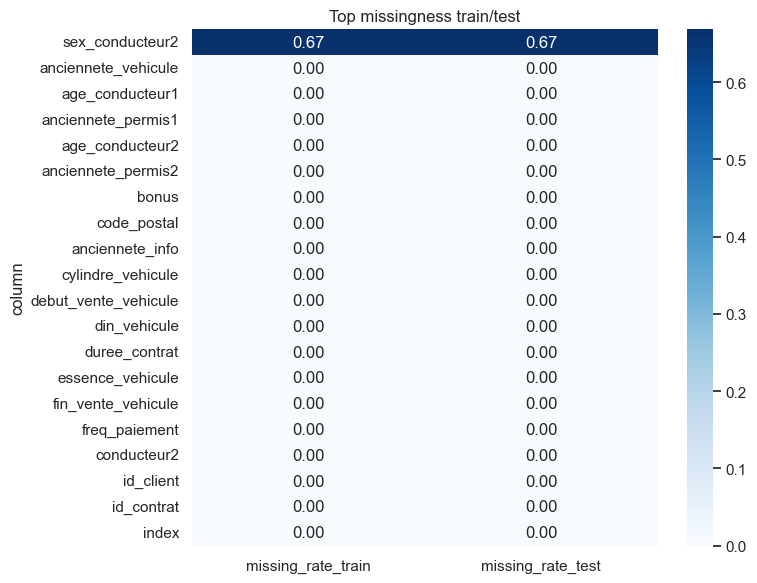

In [5]:
# Missingness global + par sous-population
missing_report = compute_missingness_report(
    train_raw, test_raw, group_cols=["utilisation", "type_vehicule", "conducteur2"]
)
missing_global = missing_report[missing_report["scope"] == "global"].copy()
missing_global = missing_global.sort_values("missing_rate_train_filled", ascending=False)
display(missing_global.head(20))

missing_qc = pd.DataFrame([
    {
        "check": "train_only_columns_count",
        "value": int(((missing_global["present_train"] == 1) & (missing_global["present_test"] == 0)).sum()),
    },
    {
        "check": "unexpected_nan_missing_rate_test_on_present_test_cols",
        "value": int(
            missing_global.loc[missing_global["present_test"] == 1, "missing_rate_test_effective"].isna().sum()
        ),
    },
    {
        "check": "unexpected_nan_missing_rate_train_on_present_train_cols",
        "value": int(
            missing_global.loc[missing_global["present_train"] == 1, "missing_rate_train_effective"].isna().sum()
        ),
    },
])
display(missing_qc)

pivot_missing = (
    missing_global[["column","missing_rate_train_filled","missing_rate_test_filled"]]
    .rename(columns={"missing_rate_train_filled":"missing_rate_train", "missing_rate_test_filled":"missing_rate_test"})
    .set_index("column")
    .sort_values("missing_rate_train", ascending=False)
    .head(20)
)
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_missing, annot=True, fmt=".2f", cmap="Blues")
plt.title("Top missingness train/test")
plt.tight_layout()

missing_group = missing_report[missing_report["scope"] == "by_group"].copy()
display(missing_group.sort_values("missing_rate_train", ascending=False).head(20))


In [6]:
# RÃ¨gles mÃ©tier / incohÃ©rences / petits sinistres / zÃ©ros techniques
rule_violations = compute_rule_violations(train_raw)
display(rule_violations)

zero_tech = pd.DataFrame([
    {
        "column": c,
        "zero_rate_train": float((pd.to_numeric(train_raw[c], errors='coerce') == 0).mean()),
        "zero_rate_test": float((pd.to_numeric(test_raw[c], errors='coerce') == 0).mean()) if c in test_raw.columns else np.nan,
    }
    for c in ["poids_vehicule", "cylindre_vehicule"]
    if c in train_raw.columns
])
display(zero_tech)


,check_name,rule,n_violations,ratio_violations,example_indices
0,poids_zero_or_neg,poids_vehicule <= 0,1883,0.03766,"28,36,42,45,48"
1,permis_gt_age_conducteur2,anciennete_permis2 > age_conducteur2,397,0.00794,"99,133,154,221,550"
2,permis_gt_age_conducteur1,anciennete_permis1 > age_conducteur1,12,0.00024,"1044,1345,1346,12595,21824"
3,cylindre_zero_or_neg,cylindre_vehicule <= 0,3,0.00006,"41748,41750,46971"
4,age_conducteur1_impossible,"age_conducteur1 out of [16,100]",1,0.00002,6851
5,sinistre_negatif,montant_sinistre < 0,0,0.00000,
6,petit_sinistre_lt_50,0 < montant_sinistre < 50,0,0.00000,


,column,zero_rate_train,zero_rate_test
0,poids_vehicule,0.03766,0.03722
1,cylindre_vehicule,0.00006,0.00004


## Discussion attendue: sinistres nÃ©gatifs, petits sinistres, extrÃªmes

**Constat**
- Le dataset peut contenir des valeurs atypiques (nÃ©gatives, trÃ¨s petites, extrÃªmes).

**InterprÃ©tation**
- En assurance, ces cas peuvent reflÃ©ter des conventions de gestion, des remboursements, ou du bruit.

**DÃ©cision (Ã  dÃ©fendre en soutenance)**
- Tagger systÃ©matiquement ces cas.
- Comparer plusieurs stratÃ©gies (laisser / winsoriser pour l'apprentissage / traiter la queue sÃ©parÃ©ment).
- Ne jamais masquer une dÃ©cision de nettoyage sans trace analytique.


In [7]:
# Doublons exacts et quasi-doublons (hors cible)
n_dup_exact = int(train_raw.duplicated().sum())
feature_cols_wo_target = [c for c in train_raw.columns if c not in [v2.TARGET_FREQ_COL, v2.TARGET_SEV_COL]]
n_dup_wo_target = int(train_raw.duplicated(subset=feature_cols_wo_target).sum())
dup_report = pd.DataFrame([
    {"check": "duplicate_rows_exact", "count": n_dup_exact},
    {"check": "duplicate_rows_wo_target", "count": n_dup_wo_target},
])
display(dup_report)


,check,count
0,duplicate_rows_exact,0
1,duplicate_rows_wo_target,0


In [8]:
# Drift train/test numÃ©rique + catÃ©goriel + cardinalitÃ©
excluded_core = set([v2.INDEX_COL, *v2.ID_COLS, v2.TARGET_FREQ_COL, v2.TARGET_SEV_COL])
num_cols = [c for c in train_raw.columns if str(train_raw[c].dtype).startswith(("int","float")) and c in test_raw.columns]
cat_cols = [c for c in train_raw.columns if train_raw[c].dtype == "object" and c in test_raw.columns and c not in excluded_core]

drift_num = compute_drift_numeric_ks_psi(train_raw, test_raw, num_cols=num_cols, bins=10, include_ids=False)
drift_cat = compute_drift_categorical_chi2(train_raw, test_raw, cat_cols=cat_cols, top_k=50)
cardinality = build_cardinality_report(train_raw, test_raw)
ood = v2.compute_ood_diagnostics(train_raw.astype(object), test_raw.astype(object))
drift_num_focus = drift_num[~drift_num["column"].isin(excluded_core)].copy()

display(drift_num_focus.head(20))
display(drift_cat.head(20))
display(cardinality.head(20))
display(ood.sort_values("unseen_test_levels", ascending=False).head(20))


,column,n_train_non_null,n_test_non_null,mean_train,mean_test,median_train,median_test,std_train,std_test,ks_stat,ks_pvalue,psi
0,din_vehicule,50000,50000,91.547520,91.237380,87.0,87.0,34.489591,34.131069,0.004980,0.563030,0.000662
1,anciennete_vehicule,49999,50000,9.531091,9.572820,8.0,8.0,7.012082,7.041990,0.003815,0.858702,0.000603
2,vitesse_vehicule,50000,50000,170.731340,170.634680,170.0,170.0,23.441265,23.293836,0.004020,0.812341,0.000483
3,poids_vehicule,50000,50000,1129.088460,1127.326580,1130.0,1125.0,361.002771,360.272977,0.005560,0.420691,0.000365
4,prix_vehicule,50000,50000,18095.562080,18021.820880,16250.0,16200.0,8715.016777,8610.964544,0.004520,0.684922,0.000349
5,debut_vente_vehicule,50000,50000,11.628320,11.679120,10.0,10.0,7.756015,7.823188,0.004180,0.773250,0.000319
6,fin_vente_vehicule,50000,50000,8.653180,8.693160,7.0,7.0,6.619835,6.667459,0.004180,0.773250,0.000298
7,anciennete_permis1,50000,50000,32.444980,32.534720,32.0,33.0,13.470294,13.460016,0.003860,0.848880,0.000247
8,bonus,50000,50000,0.537911,0.536762,0.5,0.5,0.098998,0.097089,0.005340,0.472364,0.000228
9,age_conducteur1,50000,50000,54.649940,54.717700,54.0,54.0,14.865299,14.877991,0.003880,0.844476,0.000202


,column,train_unique,test_unique,unseen_test_levels,unseen_ratio_on_test_levels,unseen_ratio_on_test_rows,chi2_stat_topk,chi2_pvalue_topk,chi2_dof_topk,top_train_levels
0,code_postal,12790,12806,5004,0.390754,0.14964,68.311791,0.125161,56.0,31555 | 67482 | 06088 | 59350 | 75115 | 44109 ...
1,modele_vehicule,886,894,137,0.153244,0.00412,37.104331,0.911902,50.0,CLIO | 206 | TWINGO | SCENIC | MEGANE | 307 | ...
2,marque_vehicule,89,88,12,0.136364,0.00038,42.642447,0.819319,52.0,RENAULT | PEUGEOT | CITROEN | VOLKSWAGEN | FOR...
3,type_contrat,4,4,0,0.000000,0.00000,3.112860,0.374550,3.0,Maxi | Median2 | Median1 | Mini
4,freq_paiement,4,4,0,0.000000,0.00000,3.761547,0.288391,3.0,Yearly | Monthly | Biannual | Quarterly
5,paiement,2,2,0,0.000000,0.00000,0.006282,0.936826,1.0,No | Yes
6,utilisation,4,4,0,0.000000,0.00000,2.508432,0.473769,3.0,WorkPrivate | Retired | Professional | AllTrips
7,conducteur2,2,2,0,0.000000,0.00000,0.000045,0.994642,1.0,No | Yes
8,sex_conducteur1,2,2,0,0.000000,0.00000,0.001503,0.969080,1.0,M | F
9,sex_conducteur2,3,3,0,0.000000,0.00000,1.571064,0.455877,2.0,nan | F | M


,column,dtype_train,nunique_train,nunique_test,top1_ratio_train,rare_ratio_train_lt10
0,index,int64,50000,50000.0,0.00002,1.000000
1,id_contrat,object,50000,NaN,0.00002,1.000000
2,id_client,object,45785,NaN,0.00010,1.000000
3,code_postal,object,12790,12806.0,0.00490,0.928225
4,prix_vehicule,int64,4752,4691.0,0.01014,0.780934
5,montant_sinistre,float64,2260,NaN,0.94166,0.996018
6,poids_vehicule,int64,968,959.0,0.03766,0.501033
7,modele_vehicule,object,886,894.0,0.07214,0.586907
8,cylindre_vehicule,int64,532,521.0,0.06476,0.535714
9,din_vehicule,int64,207,205.0,0.09224,0.352657


,diagnostic_type,feature,train_unique,test_unique,unseen_test_levels,unseen_ratio_on_levels
0,ood,index,50000,50000,50000,1.000000
8,ood,code_postal,12790,12806,5004,0.390754
26,ood,prix_vehicule,4752,4691,1173,0.250053
21,ood,modele_vehicule,886,894,137,0.153244
27,ood,poids_vehicule,968,959,98,0.102190
17,ood,cylindre_vehicule,532,521,82,0.157390
18,ood,din_vehicule,207,205,22,0.107317
20,ood,marque_vehicule,89,88,12,0.136364
24,ood,vitesse_vehicule,176,174,9,0.051724
1,ood,bonus,73,69,7,0.101449


In [9]:
# Tableau "Anomalie -> dÃ©cision -> impact modÃ¨le" (exportable)
anomaly_decision_impact = pd.DataFrame([
    {
        "anomaly": "IDs / identifiants",
        "decision": "Exclure comme features brutes",
        "impact_modele": "RÃ©duit fuite et mÃ©morisation non gÃ©nÃ©ralisable",
    },
    {
        "anomaly": "ZÃ©ros techniques (poids/cylindre)",
        "decision": "Recode en NA + indicateur is_missing",
        "impact_modele": "Ã‰vite signal numÃ©rique faux et conserve information de qualitÃ©",
    },
    {
        "anomaly": "NA structurels conducteur2",
        "decision": "Imputation conditionnelle + flag has_second_driver",
        "impact_modele": "PrÃ©serve le sens mÃ©tier des NA",
    },
    {
        "anomaly": "OOD catÃ©goriel (code postal / modÃ¨le)",
        "decision": "HiÃ©rarchies cp2/cp3 + rare grouping + fallback",
        "impact_modele": "AmÃ©liore robustesse train/test",
    },
    {
        "anomaly": "Queue lourde sÃ©vÃ©ritÃ©",
        "decision": "log1p/Tweedie + audit de distribution/tail",
        "impact_modele": "RÃ©duit sous-couverture des extrÃªmes",
    },
])
display(anomaly_decision_impact)


,anomaly,decision,impact_modele
0,IDs / identifiants,Exclure comme features brutes,RÃ©duit fuite et mÃ©morisation non gÃ©nÃ©ralis...
1,ZÃ©ros techniques (poids/cylindre),Recode en NA + indicateur is_missing,Ã‰vite signal numÃ©rique faux et conserve info...
2,NA structurels conducteur2,Imputation conditionnelle + flag has_second_dr...,PrÃ©serve le sens mÃ©tier des NA
3,OOD catÃ©goriel (code postal / modÃ¨le),HiÃ©rarchies cp2/cp3 + rare grouping + fallback,AmÃ©liore robustesse train/test
4,Queue lourde sÃ©vÃ©ritÃ©,log1p/Tweedie + audit de distribution/tail,RÃ©duit sous-couverture des extrÃªmes


**Ã€ commenter (drift/OOD)**

- `Constat`: OOD fort sur granularitÃ© fine (ex. `code_postal`, `modele_vehicule`) vs plus faible sur agrÃ©gats (`cp2/cp3`).
- `InterprÃ©tation`: certaines colonnes demandent hiÃ©rarchies/fallbacks plutÃ´t qu'un traitement brut.
- `DÃ©cision`: prioriser robustesse OOD (rare grouping, TE cross-fit, hiÃ©rarchies gÃ©ographiques).


In [10]:
# Justification du split / validation anti-fuite
splits = v2.build_split_registry(train_raw, n_blocks_time=5, n_splits_group=5, group_col="id_client")
split_rows = []
for split_name, folds in splits.items():
    v2.validate_folds_disjoint(
        folds,
        check_full_coverage=(split_name in {"secondary_group", "aux_blocked5"}),
        n_rows=len(train_raw),
    )
    if split_name == "secondary_group":
        v2.validate_group_disjoint(folds, train_raw["id_client"])
    for fold_id, (tr_idx, va_idx) in folds.items():
        split_rows.append(
            {
                "split": split_name,
                "fold_id": int(fold_id),
                "n_train": int(len(tr_idx)),
                "n_valid": int(len(va_idx)),
            }
        )
split_summary = pd.DataFrame(split_rows)
display(split_summary)


,split,fold_id,n_train,n_valid
0,primary_time,1,10000,10000
1,primary_time,2,20000,10000
2,primary_time,3,30000,10000
3,primary_time,4,40000,10000
4,secondary_group,1,40000,10000
5,secondary_group,2,40000,10000
6,secondary_group,3,40000,10000
7,secondary_group,4,40000,10000
8,secondary_group,5,40000,10000
9,aux_blocked5,1,40000,10000


## OOF / GroupKFold / anti-fuite (rappel pÃ©dagogique)

- **GroupKFold**: toutes les lignes d'un mÃªme `id_client` restent dans le mÃªme fold.
- **OOF**: chaque ligne est prÃ©dite par un modÃ¨le qui ne l'a jamais vue.
- **Pourquoi c'est crucial ici**: sinon, on mesure un score optimiste et on augmente le risque de shake-up public/privÃ©.


In [11]:
# Exports d'analyse (Notebook 1)
tables = {
    "data_dictionary": data_dict,
    "column_typing_report": col_types,
    "leakage_risk_report": leakage_risk,
    "missingness_report": missing_report,
    "rule_violations_report": rule_violations,
    "drift_numeric_ks_psi": drift_num,
    "drift_categorical_chi2": drift_cat,
    "cardinality_report": cardinality,
    "anomaly_decision_impact": anomaly_decision_impact,
}
export_analysis_tables(tables, ARTIFACT_DS)
print("Exports DS notebook 1 ->", ARTIFACT_DS)


Exports DS notebook 1 -> c:\Users\icemo\Downloads\Calcul-prime-d-assurance\artifacts\ds


## SynthÃ¨se Notebook 1 (Ã  complÃ©ter)

**Risques identifiÃ©s**
- [ ] fuite via identifiants
- [ ] OOD catÃ©goriel sur granularitÃ© fine
- [ ] extrÃªmes de sÃ©vÃ©ritÃ© / queue lourde
- [ ] incohÃ©rences et zÃ©ros techniques

**Mitigations retenues**
- [ ] split multi-schÃ©mas (`primary_time`, `secondary_group`, `aux_blocked5`)
- [ ] hiÃ©rarchies/fallbacks OOD
- [ ] traitements robustes de sÃ©vÃ©ritÃ© (log/Tweedie/tail mapping)
- [ ] traÃ§abilitÃ© des rÃ¨gles de nettoyage


## Ce qui est attendu en soutenance (check rapide)

- Montrer **au moins 3 constats data** qui justifient le modÃ¨le (raretÃ©, queue lourde, OOD).
- Justifier **explicitement** le split `GroupKFold(id_client)` (anti-fuite).
- Montrer une table `anomalie -> dÃ©cision -> impact modÃ¨le`.
- Expliquer pourquoi un bon score public n'est **pas suffisant** sans robustesse locale.


## Export standardis? des sorties DS (CSV + PNG)

Cette cellule sauvegarde les tables et figures dans `artifacts/ds/` via `ds_reporting`.


In [12]:
# DS_OUTPUT_EXPORT_CELL_V1
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from src.insurance_pricing.runtime.ds_reporting import save_table, save_figure, export_ds_tables_and_figures

NOTEBOOK_NAME = '07_ds_cadrage_qualite_cv.ipynb'
DS_ROOT = Path('artifacts/ds')

# Export tables disponibles (compat notebooks existants)
for csv_path in sorted(DS_ROOT.glob('*.csv')):
    try:
        df = pd.read_csv(csv_path)
        save_table(df, csv_path.stem, NOTEBOOK_NAME)
    except Exception:
        pass

# Figure l?g?re de synth?se (si m?triques dispo)
metrics_path = DS_ROOT / 'oof_model_diagnostics_metrics.csv'
if metrics_path.exists():
    m = pd.read_csv(metrics_path)
    if not m.empty and 'q99_ratio_pos' in m.columns:
        fig, ax = plt.subplots(figsize=(7, 3.5))
        q = pd.to_numeric(m['q99_ratio_pos'], errors='coerce').dropna()
        if len(q):
            ax.plot(range(len(q)), q, marker='o')
            ax.axhline(1.0, linestyle='--', color='red', linewidth=1)
            ax.set_title('q99_ratio_pos - diagnostic')
            ax.set_xlabel('run')
            ax.set_ylabel('ratio')
            save_figure(fig, 'q99_ratio_pos_notebook', NOTEBOOK_NAME, dpi=160)
        plt.close(fig)

# Export batch standardis?
_ = export_ds_tables_and_figures(mode='full')
print('DS exports updated for', NOTEBOOK_NAME)



DS exports updated for 07_ds_cadrage_qualite_cv.ipynb
